In [ ]:
#Step 1
# Importing Numpy and Pandas Libraries for numerical data and performing file manipulation
import numpy as np
import pandas as pd

In [ ]:
#Step 2
df = pd.read_csv("myTitanicDataSet.csv") # Dataset Loading
print(df.head(8)) # or df.head() # Display the first eight rows

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   
5          897         0       3   
6          898         1       3   
7          899         0       2   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
5                    Svensson, Mr. Johan Cervin    male  14.0      0      0   
6                          Connolly, Miss. Kate  female  30.0      0      0   
7                  Caldwell, Mr. Albert Fra

In [ ]:
#Step 3
# Data Cleaning - 1
print(df.isnull().sum()) # Check missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# Data Cleaning - 2
df['Age'].fillna(df['Age'].median(), inplace=True) # Fill missing Age with median

/tmp/ipykernel_1618/3619972792.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True) # Fill missing Age with median


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# Data Cleaning - 3
df['Fare'].fillna(df['Fare'].median(), inplace=True) # Fill missing Fare

/tmp/ipykernel_1618/2747311473.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(), inplace=True) # Fill missing Fare


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# Data Cleaning - 4
df.dropna(subset=['Embarked'], inplace=True) # Drop rows with missing Embarked

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [ ]:
# Step 4
#Feature Engineering - 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 # Create Family Size

In [ ]:
#Feature Engineering -2
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) # Convert categorical variables called Sex to numeric
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}) # Convert categorical variables called Embarked to numeric

In [ ]:
# Importing Libraries for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

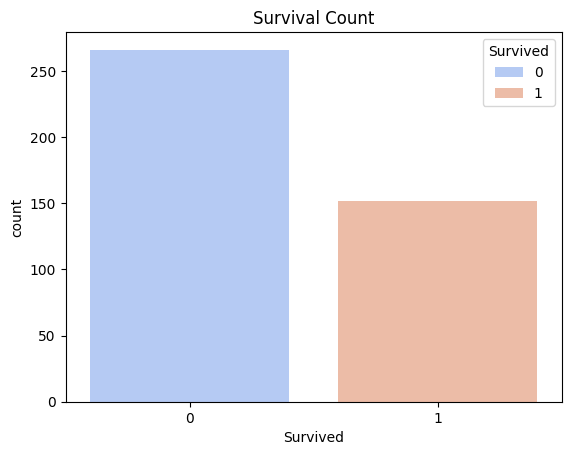

In [ ]:
#Step 5
# Data Visualization - 1
# Survival Count
sns.countplot(x='Survived', hue='Survived', data=df, palette='coolwarm')
plt.title("Survival Count")
plt.show()

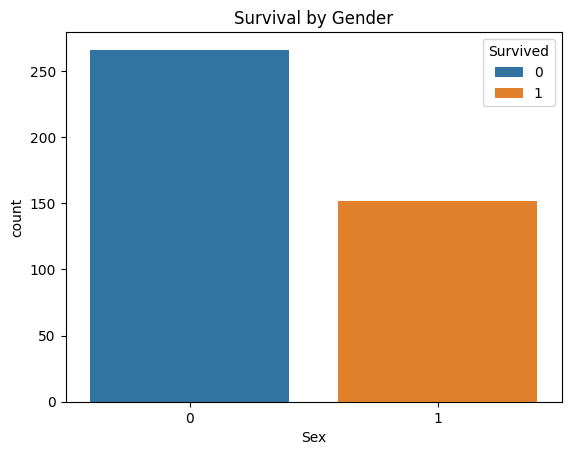

In [ ]:
# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

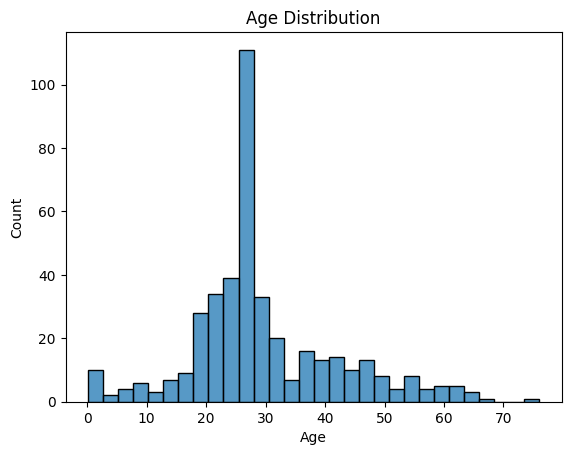

In [ ]:
# Data Visualization - 3
sns.histplot(df['Age'], bins=30) # Age Distribution Visualization using Histogram
plt.title("Age Distribution")
plt.show()

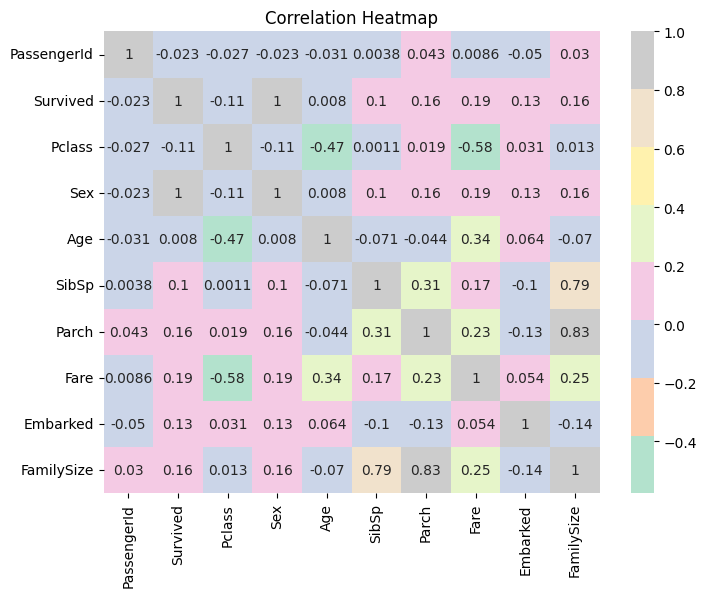

In [ ]:
# Data Visualization - 4
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='Pastel2', annot=True) # Correlation Heatmap
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Step 6
X = df[['Age', 'Sex', 'Pclass', 'Fare', 'FamilySize']] #Select Features and Target
y = df['Survived']

In [ ]:
# Importing Libraries for Model Building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Step 7
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Stp 8
# Build Logistic Regression Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
# Step 9
# Make Predictions
y_pred = model.predict(X_test)

In [ ]:
#Step 10
# Evaluate Model - 1
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
# Evaluate Model - 2
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[50  0]
 [ 0 34]]


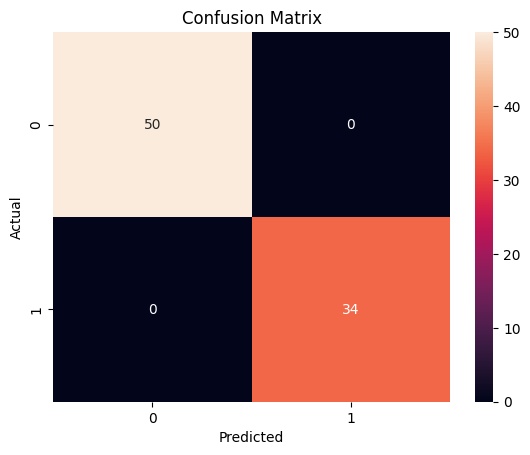

In [ ]:
# Evaluate 0 - 3
# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()